In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [87]:
import scipy.stats as stats

In [88]:
df= pd.read_csv('Bengaluru_House_Data.csv')

In [89]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [91]:
df.isna().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [92]:
def convert_sqft(x):
    if isinstance(x, str):
        tokens = x.split('-')
        if len(tokens) == 2:
            return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

In [93]:
df.isna().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft        46
bath              73
balcony          609
price              0
dtype: int64

In [94]:
from sklearn.impute import SimpleImputer

In [95]:
imputer3 = SimpleImputer()

df['total_sqft']= imputer3.fit_transform(df[['total_sqft']])

In [96]:
df.isna().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [97]:
df.describe(include='number')

,total_sqft,bath,balcony,price
count,13320.000000,13247.000000,12711.000000,13320.000000
mean,1559.626694,2.692610,1.584376,112.565627
std,1236.264860,1.341458,0.817263,148.971674
min,1.000000,1.000000,0.000000,8.000000
25%,1100.000000,2.000000,1.000000,50.000000
50%,1279.500000,2.000000,2.000000,72.000000
75%,1678.000000,3.000000,2.000000,120.000000
max,52272.000000,40.000000,3.000000,3600.000000


# Box-Pox Tranform

In [98]:
from sklearn.preprocessing import PowerTransformer

In [99]:
trans = PowerTransformer(method='box-cox')

In [100]:
df['total_sqft_trans']= trans.fit_transform(df[['total_sqft']])

In [101]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,total_sqft_trans
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,1.0,39.07,-0.578435
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,1.374453
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440.0,2.0,3.0,62.00,0.096874
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,1.0,95.00,0.215692
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200.0,2.0,1.0,51.00,-0.299707


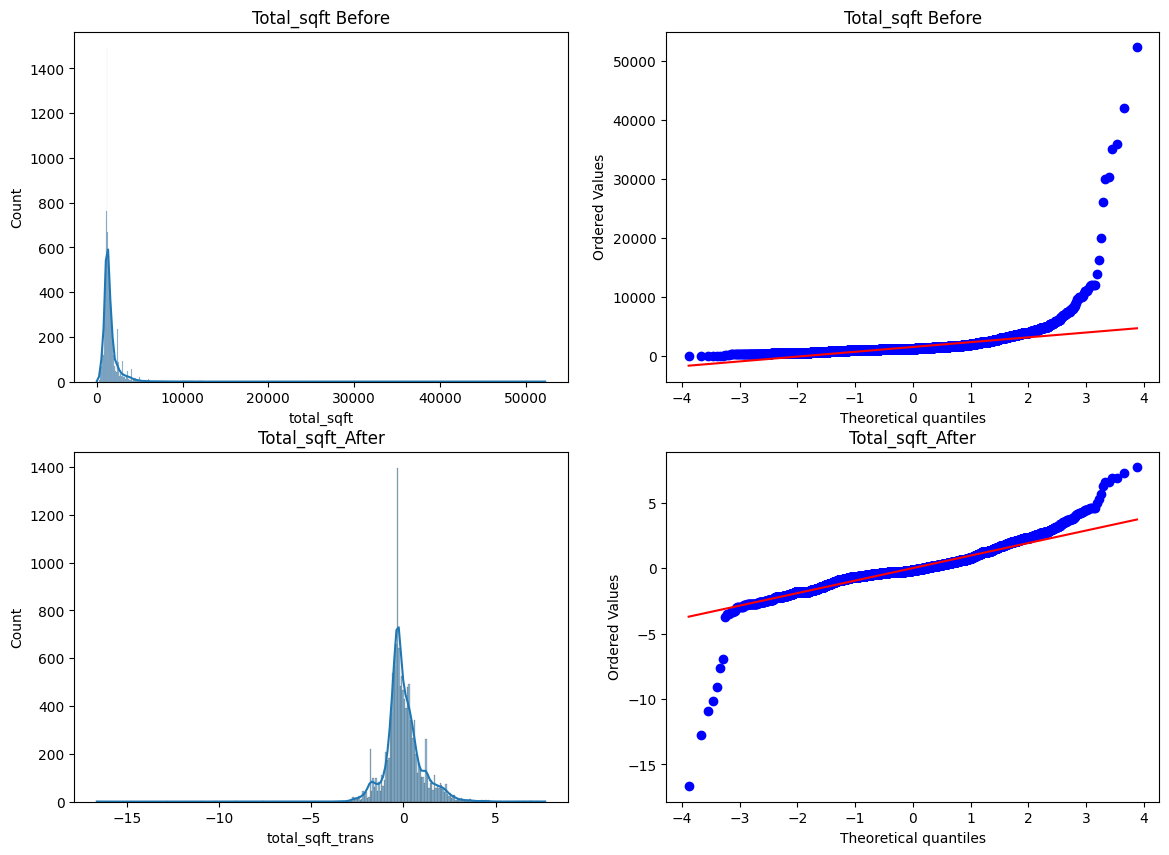

In [102]:
plt.figure(figsize=(14,10))
plt.subplot(2,2,1)
sns.histplot(x='total_sqft', data=df, kde=True)
plt.title('Total_sqft Before')


plt.subplot(2,2,2)
stats.probplot(df['total_sqft'], dist='norm', plot=plt)
plt.title('Total_sqft Before')

plt.subplot(2,2,3)
sns.histplot(x='total_sqft_trans', data=df, kde=True)
plt.title('Total_sqft_After')

plt.subplot(2,2,4)
stats.probplot(df['total_sqft_trans'], dist='norm', plot=plt)
plt.title('Total_sqft_After')

plt.show()


# Yeo-Jhonson Tranformer

In [103]:
trans2 = PowerTransformer(method='yeo-johnson')

In [104]:
df['total_sqft_trans2']=trans2.fit_transform(df[['total_sqft']])

In [105]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,total_sqft_trans,total_sqft_trans2
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,1.0,39.07,-0.578435,-0.577952
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,1.374453,1.375086
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440.0,2.0,3.0,62.00,0.096874,0.100530
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,1.0,95.00,0.215692,0.219568
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200.0,2.0,1.0,51.00,-0.299707,-0.297519


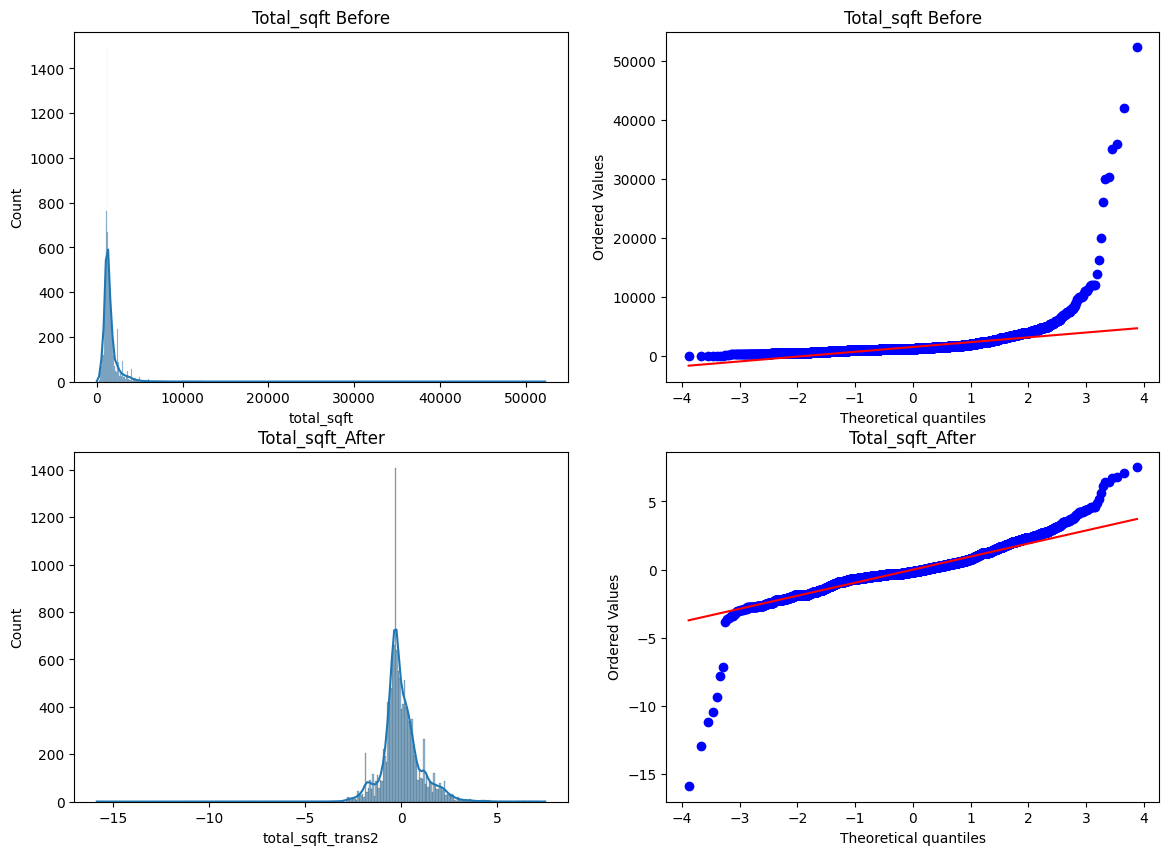

In [106]:
plt.figure(figsize=(14,10))
plt.subplot(2,2,1)
sns.histplot(x='total_sqft', data=df, kde=True)
plt.title('Total_sqft Before')


plt.subplot(2,2,2)
stats.probplot(df['total_sqft'], dist='norm', plot=plt)
plt.title('Total_sqft Before')

plt.subplot(2,2,3)
sns.histplot(x='total_sqft_trans2', data=df, kde=True)
plt.title('Total_sqft_After')

plt.subplot(2,2,4)
stats.probplot(df['total_sqft_trans2'], dist='norm', plot=plt)
plt.title('Total_sqft_After')

plt.show()
